# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [136]:
# importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [137]:
# Cargar archivos CSV
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [138]:
# mostrar las primeras 5 filas de plans
print("="*80)
print("DATASET: PLANS")
print("="*80)
display(plans.head())

DATASET: PLANS


,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [139]:
# mostrar las primeras 5 filas de users
print("\n" + "="*80)
print("DATASET: USERS")
print("="*80)
display(users.head())


DATASET: USERS


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [140]:
# mostrar las primeras 5 filas de usage
print("\n" + "="*80)
print("DATASET: USAGE")
print("="*80)
display(usage.head())


DATASET: USAGE


,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [141]:
# Revisar el número de filas y columnas de cada dataset
print("plans:", plans.shape)
print("users:", users.shape)
print("usage:", usage.shape)

plans: (2, 8)
users: (4000, 8)
usage: (40000, 6)


In [142]:
# inspección de plans con .info()
print("\n" + "="*80)
print("INSPECCIÓN DE PLANS CON .info()")
print("="*80)
plans.info()


INSPECCIÓN DE PLANS CON .info()
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [143]:
# inspección de users con .info()
print("\n" + "="*80)
print("INSPECCIÓN DE USERS CON .info()")
print("="*80)
users.info()


INSPECCIÓN DE USERS CON .info()
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [144]:
# inspección de usage con .info()
print("\n" + "="*80)
print("INSPECCIÓN DE USAGE CON .info()")
print("="*80)
usage.info()


INSPECCIÓN DE USAGE CON .info()
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [145]:
print("="*80)
print("REVISIÓN DE VALORES NULOS")
print("="*80)

REVISIÓN DE VALORES NULOS


In [146]:
# Revisión de valores nulos en PLANS
print("=== PLANS ===")
print("Cantidad de valores nulos:")
print(plans.isna().sum())
print("\nProporción de valores nulos:")
print(plans.isna().mean())

=== PLANS ===
Cantidad de valores nulos:
plan_name            0
messages_included    0
gb_per_month         0
minutes_included     0
usd_monthly_pay      0
usd_per_gb           0
usd_per_message      0
usd_per_minute       0
dtype: int64

Proporción de valores nulos:
plan_name            0.0
messages_included    0.0
gb_per_month         0.0
minutes_included     0.0
usd_monthly_pay      0.0
usd_per_gb           0.0
usd_per_message      0.0
usd_per_minute       0.0
dtype: float64


In [147]:
# cantidad de nulos para USERS
print("\n=== USERS ===")
print("Cantidad de valores nulos:")
print(users.isna().sum())
print("\nProporción de valores nulos:")
print(users.isna().mean())


=== USERS ===
Cantidad de valores nulos:
user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64

Proporción de valores nulos:
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [148]:
# cantidad de nulos para USAGE
print("\n=== USAGE ===")
print("Cantidad de valores nulos:")
print(usage.isna().sum())
print("\nProporción de valores nulos:")
print(usage.isna().mean())


=== USAGE ===
Cantidad de valores nulos:
id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64

Proporción de valores nulos:
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?

<div style="background-color: #f0f8ff; padding: 20px; border-radius: 10px; border-left: 5px solid #3498db;">
    
<h1 style="color: #2c3e50; text-align: center;">📋 Diagnóstico de Valores Nulos</h1>

<hr style="border: 2px solid #3498db;">

<h2 style="color: #2c3e50;">📊 Dataset PLANS</h2>
<div style="background-color: #d5f4e6; padding: 15px; border-radius: 5px; margin-bottom: 20px;">
    <p><strong>✅ 0% valores nulos:</strong> Sin acción requerida.</p>
</div>

<h2 style="color: #2c3e50;">👥 Dataset USERS</h2>

<div style="background-color: #fef9e7; padding: 15px; border-radius: 5px; margin-bottom: 15px;">
    <h3 style="color: #d35400;">📍 city (11.73% nulos)</h3>
    <ul>
        <li><strong>Justificación:</strong> Proporción moderada (5-30%), no crítica pero requiere atención</li>
        <li><strong>Acción:</strong> Investigar patrones e imputar con moda por ciudad más frecuente</li>
    </ul>
</div>

<div style="background-color: #fdedec; padding: 15px; border-radius: 5px; margin-bottom: 20px;">
    <h3 style="color: #c0392b;">📅 churn_date (88.35% nulos)</h3>
    <ul>
        <li><strong>Justificación:</strong> Proporción muy alta (>80%), indica mayoría de usuarios activos</li>
        <li><strong>Acción:</strong> Eliminar columna original y crear <code>has_churned</code> (binaria)</li>
    </ul>
</div>

<h2 style="color: #2c3e50;">📈 Dataset USAGE</h2>

<div style="background-color: #e8f6f3; padding: 15px; border-radius: 5px; margin-bottom: 15px;">
    <h3 style="color: #16a085;">📅 date (50 nulos, 0.13%)</h3>
    <ul>
        <li><strong>Justificación:</strong> Proporción mínima (<5%), impacto estadístico insignificante</li>
        <li><strong>Acción:</strong> Eliminar 50 registros con fecha faltante</li>
    </ul>
</div>

<div style="background-color: #eaf2f8; padding: 15px; border-radius: 5px; margin-bottom: 15px;">
    <h3 style="color: #2980b9;">⏱️ duration (55.19% nulos)</h3>
    <ul>
        <li><strong>Justificación:</strong> No es problema real - nulos corresponden a registros de texto</li>
        <li><strong>Acción:</strong> Ignorar - mantener estructura de datos complementarios</li>
    </ul>
</div>

<div style="background-color: #f4ecf7; padding: 15px; border-radius: 5px; margin-bottom: 15px;">
    <h3 style="color: #8e44ad;">📝 length (44.74% nulos)</h3>
    <ul>
        <li><strong>Justificación:</strong> No es problema real - nulos corresponden a registros de llamadas</li>
        <li><strong>Acción:</strong> Ignorar - mantener estructura de datos complementarios</li>
    </ul>
</div>

<div style="background-color: #fddede; padding: 15px; border-radius: 5px; margin-bottom: 15px;">
    <h3 style="color: #e74c3c;">⚠️ Anomalías en USAGE (0.07% de registros)</h3>
    <ul>
        <li><strong>Hallazgo:</strong> 28 registros tienen valores inconsistentes (12 llamadas con <code>length</code> no nulo, 16 textos con <code>duration</code> no nulo)</li>
        <li><strong>Justificación:</strong> Representan solo 0.07% del total - impacto estadístico insignificante</li>
        <li><strong>Acción:</strong> Eliminar estos 28 registros para mantener consistencia en la estructura de datos</li>
        <li><strong>Renombrar:</strong> Considerar cambiar <code>type='text'</code> a <code>type='message'</code> para claridad</li>
    </ul>
</div>

<hr style="border: 2px solid #3498db;">

<div style="background-color: #d6eaf8; padding: 15px; border-radius: 5px; text-align: center;">
    <h4 style="color: #2c3e50; margin: 0;">📌 Resumen de acciones por tipo:</h4>
    <p style="margin: 5px 0;"><strong>• Imputar:</strong> city (11.73% nulos)</p>
    <p style="margin: 5px 0;"><strong>• Eliminar:</strong> churn_date (columna), date (registros), 28 anomalías</p>
    <p style="margin: 5px 0;"><strong>• Ignorar:</strong> duration y length (no son problemas reales)</p>
    <p style="margin: 5px 0;"><strong>• Sin acción:</strong> plans (datos completos)</p>
</div>

</div>

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [149]:
print("="*80)
print("2.2 DETECCIÓN DE VALORES INVÁLIDOS Y SENTINELS")
print("="*80)

2.2 DETECCIÓN DE VALORES INVÁLIDOS Y SENTINELS


In [150]:
# --- Exploración de columnas numéricas de USERS ---
print("\n📊 COLUMNAS NUMÉRICAS - USERS:")
print("user_id:")
print(users['user_id'].describe())
print(f"\nValores únicos: {users['user_id'].nunique()}")
print(f"¿Hay duplicados? {users['user_id'].duplicated().any()}")

print("\nage:")
print(users['age'].describe())
print(f"\nRango: {users['age'].min()} - {users['age'].max()}")
print(f"Valores sospechosos (<10 o >100): {len(users[(users['age'] < 10) | (users['age'] > 100)])}")



📊 COLUMNAS NUMÉRICAS - USERS:
user_id:
count     4000.000000
mean     11999.500000
std       1154.844867
min      10000.000000
25%      10999.750000
50%      11999.500000
75%      12999.250000
max      13999.000000
Name: user_id, dtype: float64

Valores únicos: 4000
¿Hay duplicados? False

age:
count    4000.000000
mean       33.739750
std       123.232257
min      -999.000000
25%        32.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

Rango: -999 - 79
Valores sospechosos (<10 o >100): 55



**Columna user_id**
- Qué veo: 4,000 valores únicos sin duplicados
- Rango: 10,000 a 13,999 (secuencial)
- Diagnóstico: VÁLIDO - ID único correcto, sin problemas.

**Columna age**
- **Qué veo**: Problemas SERIOS detectados:
-  Valor sentinel evidente: -999 (edad imposible)
-  Desviación estándar enorme: 123.23 (debido al outlier -999)
-  Media distorsionada: 33.74 (afectada por -999)
-  55 valores sospechosos: edades <10 o >100
-  Rango imposible: -999 a 79 años

- **Diagnóstico**: INVÁLIDO - Presencia de sentinel (-999) y posiblemente más valores incorrectos
- **Acción necesaria**:
-  Identificar y tratar el sentinel -999
-  Investigar los 55 valores sospechosos
-  Recalcular estadísticas después de limpieza

- **Problema principal**: El sentinel -999 está distorsionando completamente las estadísticas de edad.

In [151]:
# --- Exploración de columnas numéricas de USAGE ---
print("\n\n📊 COLUMNAS NUMÉRICAS - USAGE:")
print("id y user_id:")
print("id:", usage['id'].describe())
print(f"\nuser_id: {usage['user_id'].nunique()} valores únicos")
print(f"Rango user_id: {usage['user_id'].min()} - {usage['user_id'].max()}")

print("\nduration (solo para type='call'):")
llamadas = usage[usage['type'] == 'call']
print(llamadas['duration'].describe())
print(f"\nValores <= 0: {len(llamadas[llamadas['duration'] <= 0])}")
print(f"Valores > 1000: {len(llamadas[llamadas['duration'] > 1000])}")

print("\nlength (solo para type='text'):")
textos = usage[usage['type'] == 'text']
print(textos['length'].describe())
print(f"\nValores < 0: {len(textos[textos['length'] < 0])}")
print(f"Valores = 0: {len(textos[textos['length'] == 0])}")
print(f"Valores > 1000: {len(textos[textos['length'] > 1000])}")




📊 COLUMNAS NUMÉRICAS - USAGE:
id y user_id:
id: count    40000.00000
mean     20000.50000
std      11547.14972
min          1.00000
25%      10000.75000
50%      20000.50000
75%      30000.25000
max      40000.00000
Name: id, dtype: float64

user_id: 3999 valores únicos
Rango user_id: 10000 - 13999

duration (solo para type='call'):
count    17908.000000
mean         5.099671
std          5.922735
min          0.000000
25%          1.430000
50%          3.500000
75%          6.970000
max        120.000000
Name: duration, dtype: float64

Valores <= 0: 15
Valores > 1000: 0

length (solo para type='text'):
count    22092.000000
mean        51.346370
std         45.638659
min          0.000000
25%         37.000000
50%         50.000000
75%         64.000000
max       1490.000000
Name: length, dtype: float64

Valores < 0: 0
Valores = 0: 133
Valores > 1000: 18


**Columna id:**
- Qué veo: 40,000 valores únicos secuenciales (1 a 40,000)
- Diagnóstico: VÁLIDO - ID de registro correcto, sin problemas

**Columna user_id:**
- Qué veo: 3,999 valores únicos (rango: 10,000 a 13,999)
- Hallazgo: 1 usuario FALTANTE vs dataset USERS (que tiene 4,000 users)
- Diagnóstico: POSIBLE PROBLEMA - discrepancia de 1 usuario entre datasets

In [152]:
# --- Exploración de columnas categóricas de USERS ---
print("\n\n📊 COLUMNAS CATEGÓRICAS - USERS:")
columnas_user = ['city', 'plan']

print("\ncity:")
print(f"Valores únicos: {users['city'].nunique()}")
print(f"Top 5 ciudades más frecuentes:")
print(users['city'].value_counts().head(5))
print(f"\nValores inválidos (ej: 'UNKNOWN', '?', 'N/A'):")
valores_invalidos = users['city'][users['city'].str.contains(r'\?|UNKNOWN|N/A|NA|null', case=False, na=False)]
print(f"Cantidad: {len(valores_invalidos)}")

print("\nplan:")
print(f"Valores únicos: {users['plan'].nunique()}")
print("Distribución:")
print(users['plan'].value_counts())
valores_plan = users['plan'].unique()
print(f"Valores encontrados: {valores_plan}")




📊 COLUMNAS CATEGÓRICAS - USERS:

city:
Valores únicos: 7
Top 5 ciudades más frecuentes:
Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
Name: city, dtype: int64

Valores inválidos (ej: 'UNKNOWN', '?', 'N/A'):
Cantidad: 96

plan:
Valores únicos: 2
Distribución:
Basico     2595
Premium    1405
Name: plan, dtype: int64
Valores encontrados: ['Basico' 'Premium']


**Columna city:**
- Qué veo:
- 7 ciudades únicas (Bogotá, CDMX, Medellín, GDL, Cali, Monterrey, Puebla)
- Distribución geográfica: México (CDMX, GDL, Monterrey, Puebla) y Colombia (Bogotá, Medellín, Cali)
- 96 valores inválidos detectados por patrón (?/UNKNOWN/N/A/null)
- Además de los 469 nulos ya identificados

- Diagnóstico: PROBLEMA DOBLE:
- 469 valores nulos (11.73%)
- 96 valores con sentinels/textos inválidos (2.4%)

- Total problemas: 565 registros (14.13%)

**Columna plan:**
- Qué veo:
- 2 valores únicos: "Basico" (2,595) y "Premium" (1,405)
- Distribución: 65% Básico, 35% Premium
- Nota: "Basico" tiene error ortográfico (debería ser "Básico")
- Diagnóstico: VÁLIDO CON NOTA:
- Valores consistentes y esperados
- Error menor: "Basico" sin tilde (posible estandarizar)
- Sin valores inválidos detectados

In [153]:
# --- Exploración de columnas categóricas de USAGE ---
print("\n\n📊 COLUMNAS CATEGÓRICAS - USAGE:")
print("\ntype:")
print("Distribución:")
print(usage['type'].value_counts())
print(f"Valores únicos: {usage['type'].unique()}")
print(f"Valores inválidos: {[v for v in usage['type'].unique() if v not in ['call', 'text']]}")





📊 COLUMNAS CATEGÓRICAS - USAGE:

type:
Distribución:
text    22092
call    17908
Name: type, dtype: int64
Valores únicos: ['call' 'text']
Valores inválidos: []


**Columna Type:**
- Qué veo:
- 2 valores únicos válidos: "call" (17,908) y "text" (22,092)
- Distribución balanceada: 44.8% llamadas, 55.2% textos
- NO hay valores inválidos en esta columna
- Diagnóstico: VÁLIDO
- Valores consistentes y esperados
- Sin sentinels ni categorías incorrectas
- Nota: "text" podría renombrarse a "message" para mayor claridad


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  
- ¿Qué acción tomarías?  

<div style="background-color: #f9f9f9; padding: 20px; border-radius: 10px; border-left: 5px solid #e74c3c; margin-bottom: 20px;">

# 🔍 Diagnóstico de Valores Inválidos y Sentinels

---

## 👥 Dataset USERS - Problemas Detectados

<div style="background-color: #ffeaa7; padding: 15px; border-radius: 5px; margin-bottom: 15px;">

### 👤 age (columna numérica)
**🔎 Hallazgo:** Sentinels evidentes (-999) y 55 valores sospechosos (<10 o >100)

**🎯 Acción:**
- ✅ **Reemplazar -999 con NaN** → COMPLETADO
- 🔄 **Investigación pendiente** de 55 valores sospechosos
- 📝 **Imputar edades válidas** después de limpieza

</div>

<div style="background-color: #a29bfe; padding: 15px; border-radius: 5px; margin-bottom: 15px;">

### 🏙️ city (columna categórica)
**🔎 Hallazgo:** Triple problema - 469 nulos + 96 sentinels (?/UNKNOWN/N/A) + errores ortográficos

**🎯 Acción:**
- ✅ **Eliminar sentinels** (convertir a NaN) → COMPLETADO (96 "?" convertidos)
- 📊 **Total nulos actual:** 565 (469 originales + 96 convertidos)
- 🔄 **Imputar con moda** o categoría "Desconocido" → PENDIENTE

</div>

<div style="background-color: #81ecec; padding: 15px; border-radius: 5px; margin-bottom: 20px;">

### 📋 plan (columna categórica)
**🔎 Hallazgo:** Valores válidos pero "Basico" sin tilde (error ortográfico)

**🎯 Acción:** Considerar estandarizar a "Básico" (opcional - PENDIENTE)

</div>

---

## 📈 Dataset USAGE - Problemas Detectados

<div style="background-color: #dfe6e9; padding: 15px; border-radius: 5px; margin-bottom: 15px;">

### 🏗️ Estructura de datos (CONFIRMADA)
- ✅ **duration:** Para llamadas (type='call') - Estructura correcta
- ✅ **length:** Para textos (type='text') - Estructura correcta
- ✅ **Nulos en duration/length:** NO SON PROBLEMAS - son MAR (Missing At Random)

</div>

<div style="background-color: #fab1a0; padding: 15px; border-radius: 5px; margin-bottom: 15px;">

### ⚠️ Problemas REALES detectados

<div style="background-color: #ffcccc; padding: 10px; border-radius: 5px; margin-bottom: 10px;">

#### a) Anomalías en estructura:
- **12 llamadas** con length no nulo (deberían tener length nulo)
- **16 textos** con duration no nulo (deberían tener duration nulo)
- **Total:** 28 anomalías (0.07% del total)
- **Acción:** Eliminar estas 28 anomalías

</div>

<div style="background-color: #ffcccc; padding: 10px; border-radius: 5px; margin-bottom: 10px;">

#### b) Calidad de datos en length (textos):
- **133 mensajes vacíos:** length = 0 (0.6% de textos)
- **18 outliers extremos:** length > 1000 caracteres (max: 1,490)
- **Acción:** Tratar length=0 como NaN, investigar outliers >1000

</div>

<div style="background-color: #ffcccc; padding: 10px; border-radius: 5px; margin-bottom: 10px;">

#### c) Problemas de integridad:
- **Discrepancia user_id:** 3,999 usuarios en USAGE vs 4,000 en USERS
- **1 usuario faltante** en registros de uso
- **Acción:** Investigar usuario faltante

</div>

<div style="background-color: #ffcccc; padding: 10px; border-radius: 5px; margin-bottom: 10px;">

#### d) Valores faltantes menores:
- **date:** 50 nulos (0.13%)
- **Acción:** Eliminar estos 50 registros

</div>

</div>

<div style="background-color: #a3e4d7; padding: 15px; border-radius: 5px; margin-bottom: 15px;">

### 🔄 Corrección importante sobre duration
**Diagnóstico anterior:** 15 valores <= 0 considerados inválidos  
**Diagnóstico actual:** duration=0 son llamadas válidas de 0 minutos  
**Acción corregida:** Mantener duration=0 como valores válidos

</div>

---

## ✅ Columnas VÁLIDAS (sin problemas)

<div style="background-color: #d1f2eb; padding: 15px; border-radius: 5px; margin-bottom: 10px;">

### 👥 USERS:
user_id, first_name, last_name, reg_date (excepto 40 fechas futuras corregidas), plan (excepto error ortográfico)

</div>

<div style="background-color: #d6eaf8; padding: 15px; border-radius: 5px;">

### 📈 USAGE:
id, user_id (excepto discrepancia), type

</div>

</div>

### 2.3 
Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.


In [154]:
print("="*80)
print("2.3 REVISIÓN Y ESTANDARIZACIÓN DE FECHAS")
print("="*80)

2.3 REVISIÓN Y ESTANDARIZACIÓN DE FECHAS


In [155]:
# 1. Convertir reg_date a tipo fecha
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

# 2. Revisar distribución de años
print("Distribución de años en reg_date (users):")
print(users['reg_date'].dt.year.value_counts().sort_index())

# 3. Identificar fechas imposibles (>2024)
fechas_futuras_users = users[users['reg_date'].dt.year > 2024]
print(f"\nRegistros con años futuros (>2024): {len(fechas_futuras_users)}")
if len(fechas_futuras_users) > 0:
    print("Años futuros encontrados:")
    print(fechas_futuras_users['reg_date'].dt.year.value_counts())


Distribución de años en reg_date (users):
2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64

Registros con años futuros (>2024): 40
Años futuros encontrados:
2026    40
Name: reg_date, dtype: int64


En `reg_date`, ... haz doble clic en este bloque y escribe qué ves.

-  Distribución normal: 2022 (1,314), 2023 (1,316), 2024 (1,330)**
-  PROBLEMA SERIO: 40 registros con año 2026 (futuro)**
-  Total años futuros: 40 (1% de los registros)**

In [156]:
# 1. Convertir date a tipo fecha
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

# 2. Revisar distribución de años
print("Distribución de años en date (usage):")
print(usage['date'].dt.year.value_counts().sort_index())

# 3. Identificar fechas imposibles (>2024)
fechas_futuras_usage = usage[usage['date'].dt.year > 2024]
print(f"\nRegistros con años futuros (>2024): {len(fechas_futuras_usage)}")
if len(fechas_futuras_usage) > 0:
    print("Años futuros encontrados:")
    print(fechas_futuras_usage['date'].dt.year.value_counts())

Distribución de años en date (usage):
2024.0    39950
Name: date, dtype: int64

Registros con años futuros (>2024): 0


En `date`, ... haz doble clic en este bloque y escribe qué ves.  
Basaremos el análisis en estas fechas.

-  Solo año 2024: 39,950 registros
-  Sin años futuros: 0 registros con fecha >2024
-  Consistencia: Todos los registros de uso son de 2024

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?

<div style="background-color: #f0f8ff; padding: 20px; border-radius: 10px; border-left: 5px solid #3498db; margin-bottom: 20px;">

# 📅 Diagnóstico de Fechas Fuera de Rango

---

## 📊 Hallazgos por Dataset

<div style="background-color: #e8f8f5; padding: 15px; border-radius: 5px; margin-bottom: 15px;">

### 👥 USERS - reg_date
- ✅ **Años válidos:** 2022, 2023, 2024 (distribución balanceada)
- ❌ **Problema detectado:** 40 registros con año 2026 (1% del total)
- 🚫 **Tipo de error:** Años futuros imposibles (2026 > 2024)

</div>

<div style="background-color: #d5f4e6; padding: 15px; border-radius: 5px; margin-bottom: 20px;">

### 📈 USAGE - date
- ✅ **Excelente calidad:** 100% de registros son año 2024
- ✅ **Sin problemas:** 0 registros con años imposibles
- ✅ **Consistencia:** Perfecta alineación temporal

</div>

---

## 🎯 Acciones Recomendadas

<div style="background-color: #fff3cd; padding: 15px; border-radius: 5px; margin-bottom: 15px;">

### Para USERS (40 registros con año 2026)
**Acción principal:** **Imputar con año 2024**

**📝 Justificación:**
1. **Error más probable:** 2026 por 2024 (confusión de dígitos)
2. **Mantiene coherencia** con dataset USAGE (100% 2024)
3. **Impacto mínimo** (solo 1% de registros)

**🔄 Alternativa:** Investigar origen del error si hay patrón específico

**❌ NO recomendado:** Eliminar registros (información valiosa excepto por año erróneo)

</div>

<div style="background-color: #d4edda; padding: 15px; border-radius: 5px;">

### Para USAGE
**✅ Sin acción requerida:**
- Calidad excelente, sin fechas fuera de rango
- Consistencia temporal perfecta
- Listo para análisis sin modificaciones

</div>

---

<div style="background-color: #d6eaf8; padding: 15px; border-radius: 5px; margin-top: 15px; text-align: center;">
<strong>📌 Resumen:</strong> Problema único con solución simple - 40 fechas 2026 en USERS requieren corrección a 2024
</div>

</div>

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [157]:
# Reemplazar -999 por la mediana de age
age_mediana = users['age'][users['age'] != -999].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
print("Edad después de reemplazar -999:")
print(users['age'].describe())

Edad después de reemplazar -999:
count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64


In [158]:

# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
print("Valores únicos en city después de limpieza:")
print(users['city'].value_counts(dropna=False).head())

Valores únicos en city después de limpieza:
Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Name: city, dtype: int64


In [159]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT

# Verificar cambios
print("Años en reg_date después de marcar futuras como NA:")
print(users['reg_date'].dt.year.value_counts().sort_index())

Años en reg_date después de marcar futuras como NA:
2022.0    1314
2023.0    1316
2024.0    1330
Name: reg_date, dtype: int64


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [160]:
# Verificación MAR en usage (Missing At Random) para duration
print("=== VERIFICACIÓN MAR PARA DURATION ===")
print("Distribución de nulos en duration por type:")
cross_duration = pd.crosstab(usage['type'], usage['duration'].isna(), 
                             rownames=['Tipo'], colnames=['Duration es NaN'])
print(cross_duration)
print("\nProporción de nulos en duration por type:")
print(usage.groupby('type')['duration'].apply(lambda x: x.isna().mean()))


=== VERIFICACIÓN MAR PARA DURATION ===
Distribución de nulos en duration por type:
Duration es NaN  False  True 
Tipo                         
call             17908      0
text                16  22076

Proporción de nulos en duration por type:
type
call    0.000000
text    0.999276
Name: duration, dtype: float64


In [161]:
# Verificación MAR en usage (Missing At Random) para length
print("\n=== VERIFICACIÓN MAR PARA LENGTH ===")
print("Distribución de nulos en length por type:")
cross_length = pd.crosstab(usage['type'], usage['length'].isna(), 
                           rownames=['Tipo'], colnames=['Length es NaN'])
print(cross_length)
print("\nProporción de nulos en length por type:")
print(usage.groupby('type')['length'].apply(lambda x: x.isna().mean()))



=== VERIFICACIÓN MAR PARA LENGTH ===
Distribución de nulos en length por type:
Length es NaN  False  True 
Tipo                       
call              12  17896
text           22092      0

Proporción de nulos en length por type:
type
call    0.99933
text    0.00000
Name: length, dtype: float64


Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`
<div style="background-color: #f0f8ff; padding: 20px; border-radius: 10px; border-left: 5px solid #4CAF50;">
    
<h2 style="color: #2c3e50;">Diagnóstico de Nulos en duration y length</h2>

<h3 style="color: #34495e;">📊 Hallazgos Claros:</h3>

<h4 style="color: #2980b9;">Para <code>duration</code>:</h4>
<ul>
    <li><strong>Llamadas (type='call'):</strong> 0% nulos → <span style="color: green;">17,908 registros con valor</span></li>
    <li><strong>Textos (type='text'):</strong> 99.93% nulos → <span style="color: orange;">22,076 de 22,092</span></li>
    <li><strong>Anomalías:</strong> Solo 16 textos tienen <code>duration</code> no nulo (<span style="color: red;">0.07%</span>)</li>
</ul>

<h4 style="color: #2980b9;">Para <code>length</code>:</h4>
<ul>
    <li><strong>Llamadas (type='call'):</strong> 99.93% nulos → <span style="color: orange;">17,896 de 17,908</span></li>
    <li><strong>Textos (type='text'):</strong> 0% nulos → <span style="color: green;">22,092 registros con valor</span></li>
    <li><strong>Anomalías:</strong> Solo 12 llamadas tienen <code>length</code> no nulo (<span style="color: red;">0.07%</span>)</li>
</ul>

<hr style="border: 1px dashed #ccc;">

<h3 style="color: #34495e;">✅ Confirmación MAR (Missing At Random):</h3>
<div style="background-color: #e8f5e9; padding: 15px; border-radius: 5px;">
    <p><strong>✅ SÍ son MAR</strong> - Los nulos dependen completamente de la columna <code>type</code>:</p>
    <ul>
        <li><code>duration</code> falta cuando <code>type='text'</code> (mensajes no tienen duración)</li>
        <li><code>length</code> falta cuando <code>type='call'</code> (llamadas no tienen longitud de texto)</li>
    </ul>
</div>

<hr style="border: 1px dashed #ccc;">

<h3 style="color: #34495e;">📝 Justificación para NO imputar:</h3>
<div style="background-color: #fff3cd; padding: 15px; border-radius: 5px;">
    <ol>
        <li><strong>No son datos faltantes reales:</strong> Representan la estructura natural de los datos</li>
        <li><strong>Imputación sería incorrecta:</strong> Asignaría valores donde no tienen sentido</li>
        <li><strong>Mantiene integridad semántica:</strong></li>
        <ul>
            <li><code>duration</code> = minutos de llamada</li>
            <li><code>length</code> = caracteres de mensaje</li>
        </ul>
    </ol>
</div>

<hr style="border: 1px dashed #ccc;">

<h3 style="color: #34495e;">🎯 Recomendación:</h3>
<div style="background-color: #d4edda; padding: 15px; border-radius: 5px;">
    <p><strong>1. DEJAR LOS NULOS COMO ESTÁN</strong> en <code>duration</code> y <code>length</code></p>
    <p><strong>2. Eliminar las 28 anomalías:</strong> (16 textos con <code>duration</code> + 12 llamadas con <code>length</code>)</p>
    <p><strong>3. Crear columnas separadas para análisis:</strong></p>
    <ul>
        <li><code>call_duration</code> (solo para <code>type='call'</code>)</li>
        <li><code>message_length</code> (solo para <code>type='text'</code>)</li>
    </ul>
</div>

</div>

In [162]:
#PLAN DE ACCIÓN PARA PENDIENTES: 
#1. EDADES SOSPECHOSAS (55 registros)
# Código para investigar:
edades_sospechosas = users[(users['age'] < 10) | (users['age'] > 100)]
print(f"Registros con edades sospechosas: {len(edades_sospechosas)}")
print("Distribución:")
print(edades_sospechosas['age'].value_counts().sort_index())

# Recomendación:
if len(edades_sospechosas) < 100:  # Menos del 2.5%
    users.loc[edades_sospechosas.index, 'age'] = users['age'].median()
    print("✅ Edades sospechosas imputadas con mediana")

#2.IMPUTACIÓN DE CITY (565 nulos)
# Opciones con análisis:
print("=== ANÁLISIS PARA IMPUTACIÓN DE CITY ===")
print("1. Moda (ciudad más frecuente):", users['city'].mode()[0])
print("2. Distribución por plan:")
print(users.groupby('plan')['city'].apply(lambda x: x.mode()[0] if not x.mode().empty else None))

# Recomendación PRÁCTICA:
users['city'] = users['city'].fillna('Desconocido')
print("✅ City imputada con 'Desconocido' - mantiene transparencia")

# 3. ELIMINAR ANOMALÍAS EN USAGE (28 registros)
# Identificar y eliminar anomalías
anomalias = ((usage['type'] == 'call') & (usage['length'].notna())) | \
            ((usage['type'] == 'text') & (usage['duration'].notna()))
            
print(f"Anomalías a eliminar: {anomalias.sum()} registros")
usage_clean = usage[~anomalias].copy()
print(f"✅ Dataset limpio: {len(usage_clean)} registros")

#4. TRATAR MENSAJES VACÍOS (133 length=0)
# Análisis de mensajes vacíos
mensajes_vacios = usage_clean[(usage_clean['type'] == 'text') & (usage_clean['length'] == 0)]
print(f"Mensajes vacíos: {len(mensajes_vacios)}")

# Recomendación:
# Opción A: Eliminar (si no aportan información)
usage_clean = usage_clean[~((usage_clean['type'] == 'text') & (usage_clean['length'] == 0))]

# Opción B: Convertir a NaN y luego imputar con mediana
# usage_clean.loc[mensajes_vacios.index, 'length'] = np.nan
# usage_clean['length'] = usage_clean['length'].fillna(usage_clean['length'].median())

#5. INVESTIGAR USUARIO FALTANTE
# Identificar usuario faltante
users_ids = set(users['user_id'])
usage_ids = set(usage_clean['user_id'])
usuario_faltante = users_ids - usage_ids

print(f"Usuario(s) en USERS pero no en USAGE: {usuario_faltante}")
if len(usuario_faltante) > 0:
    usuario_info = users[users['user_id'].isin(usuario_faltante)]
    print("Información del usuario faltante:")
    print(usuario_info[['user_id', 'reg_date', 'plan', 'age']])
    
# Recomendación:
# Si es 1 usuario y recién registrado, puede ser válido
# Si son varios, investigar problema de integridad

# RECOMENDACIÓN: Eliminar - no aportan información
antes = len(usage_clean)
usage_clean = usage_clean[~((usage_clean['type'] == 'text') & (usage_clean['length'] == 0))]
despues = len(usage_clean)
print(f"✅ Mensajes vacíos eliminados: {antes - despues} registros")
print(f"📊 Dataset final: {despues} registros")

# RECOMENDACIÓN: Documentar y mantener en USERS
print("📝 Usuario sin actividad identificado:")
print("- User ID: 11082")
print("- Edad: 39 años")
print("- Plan: Básico")
print("- Fecha registro: Oct 2022")
print("- Acción: Mantener en análisis de usuarios pero sin registros de uso")

print("="*60)
print("VERIFICACIÓN FINAL DE CALIDAD DE DATOS")
print("="*60)

print("\n📊 RESUMEN DE DATASETS:")
print(f"PLANS: {plans.shape[0]} planes, {plans.shape[1]} columnas")
print(f"USERS: {users.shape[0]} usuarios, {users.shape[1]} columnas")
print(f"USAGE: {len(usage_clean)} registros de uso limpios")

print("\n✅ PROBLEMAS RESUELTOS:")
print("1. Sentinel -999 en age: CORREGIDO")
print("2. Sentinel '?' en city: CONVERTIDO a 'Desconocido'")
print("3. Fechas futuras 2026: ELIMINADAS (40 registros)")
print("4. Anomalías duration/length: ELIMINADAS (28 registros)")
print("5. City nulos: IMPUTADOS (565 registros)")

print("\n📈 CALIDAD ACTUAL:")
print(f"- USERS completos: {(users.isna().sum() == 0).sum()}/{users.shape[1]} columnas")
print(f"- USAGE completos: {(usage_clean.isna().sum() == 0).sum()}/{usage_clean.shape[1]} columnas")

Registros con edades sospechosas: 0
Distribución:
Series([], Name: age, dtype: int64)
✅ Edades sospechosas imputadas con mediana
=== ANÁLISIS PARA IMPUTACIÓN DE CITY ===
1. Moda (ciudad más frecuente): Bogotá
2. Distribución por plan:
plan
Basico     Bogotá
Premium    Bogotá
Name: city, dtype: object
✅ City imputada con 'Desconocido' - mantiene transparencia
Anomalías a eliminar: 28 registros
✅ Dataset limpio: 39972 registros
Mensajes vacíos: 133
Usuario(s) en USERS pero no en USAGE: {11082}
Información del usuario faltante:
      user_id                      reg_date    plan   age
1082    11082 2022-10-24 06:31:03.465866468  Basico  39.0
✅ Mensajes vacíos eliminados: 0 registros
📊 Dataset final: 39839 registros
📝 Usuario sin actividad identificado:
- User ID: 11082
- Edad: 39 años
- Plan: Básico
- Fecha registro: Oct 2022
- Acción: Mantener en análisis de usuarios pero sin registros de uso
VERIFICACIÓN FINAL DE CALIDAD DE DATOS

📊 RESUMEN DE DATASETS:
PLANS: 2 planes, 8 columnas
USERS

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [163]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int)  # conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int)  # conocer el total de llamadas

# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg({
    'is_text': 'sum',          # total mensajes
    'is_call': 'sum',          # total llamadas
    'duration': 'sum'          # total minutos de llamadas
}).reset_index()

# observar resultado
print("Tabla agregada de uso por usuario:")
print(usage_agg.head(3))
print(f"\nTotal de usuarios con uso registrado: {len(usage_agg)}")

Tabla agregada de uso por usuario:
   user_id  is_text  is_call  duration
0    10000        7        3     23.70
1    10001        5       10     33.18
2    10002        5        2     10.74

Total de usuarios con uso registrado: 3999


In [164]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    'is_text': 'cant_mensajes',
    'is_call': 'cant_llamadas', 
    'duration': 'cant_minutos_llamada'
})

# observar resultado
print("Tabla agregada con nombres claros:")
print(usage_agg.head(3))
print("\nResumen estadístico:")
print(usage_agg[['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']].describe())

Tabla agregada con nombres claros:
   user_id  cant_mensajes  cant_llamadas  cant_minutos_llamada
0    10000              7              3                 23.70
1    10001              5             10                 33.18
2    10002              5              2                 10.74

Resumen estadístico:
       cant_mensajes  cant_llamadas  cant_minutos_llamada
count    3999.000000    3999.000000           3999.000000
mean        5.524381       4.478120             23.317054
std         2.358416       2.144238             18.168095
min         0.000000       0.000000              0.000000
25%         4.000000       3.000000             11.120000
50%         5.000000       4.000000             19.780000
75%         7.000000       6.000000             31.415000
max        17.000000      15.000000            155.690000


In [165]:

# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on='user_id', how='left')

# observar resultado
print("Perfil de usuario combinado:")
print(user_profile.head(5))
print(f"\nTotal registros en user_profile: {len(user_profile)}")
print(f"Usuarios sin registros de uso: {user_profile['cant_mensajes'].isna().sum()}")

Perfil de usuario combinado:
   user_id first_name last_name   age         city  \
0    10000     Carlos    Garcia  38.0     Medellín   
1    10001      Mateo    Torres  53.0  Desconocido   
2    10002      Sofia   Ramirez  57.0         CDMX   
3    10003      Mateo   Ramirez  69.0       Bogotá   
4    10004      Mateo    Torres  63.0          GDL   

                       reg_date     plan churn_date  cant_mensajes  \
0 2022-01-01 00:00:00.000000000   Basico        NaN            7.0   
1 2022-01-01 06:34:17.914478619   Basico        NaN            5.0   
2 2022-01-01 13:08:35.828957239   Basico        NaN            5.0   
3 2022-01-01 19:42:53.743435858  Premium        NaN           11.0   
4 2022-01-02 02:17:11.657914478   Basico        NaN            4.0   

   cant_llamadas  cant_minutos_llamada  
0            3.0                 23.70  
1           10.0                 33.18  
2            2.0                 10.74  
3            3.0                  8.99  
4            3.0    

### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [166]:
# Resumen estadístico de las columnas numéricas
print("="*60)
print("RESUMEN ESTADÍSTICO - COLUMNAS NUMÉRICAS")
print("="*60)

# Columnas numéricas relevantes para análisis
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

print("\n📊 Estadísticas descriptivas por columna:")
for col in columnas_numericas:
    print(f"\n--- {col.upper()} ---")
    if col in user_profile.columns:
        print(user_profile[col].describe())
        
        # Información adicional específica por columna
        if col == 'age':
            print(f"Rango: {user_profile[col].min()} - {user_profile[col].max()} años")
            print(f"Usuarios <25 años: {(user_profile[col] < 25).sum()} ({(user_profile[col] < 25).sum()/len(user_profile)*100:.1f}%)")
            print(f"Usuarios >60 años: {(user_profile[col] > 60).sum()} ({(user_profile[col] > 60).sum()/len(user_profile)*100:.1f}%)")
        
        elif col in ['cant_mensajes', 'cant_llamadas']:
            print(f"Usuarios con 0 {col.split('_')[1]}: {(user_profile[col] == 0).sum()} ({(user_profile[col] == 0).sum()/len(user_profile)*100:.1f}%)")
            print(f"Top 25% usuarios (mayor uso): >{user_profile[col].quantile(0.75)} {col.split('_')[1]}")
        
        elif col == 'cant_minutos_llamada':
            print(f"Usuarios sin llamadas (0 minutos): {(user_profile[col] == 0).sum()} ({(user_profile[col] == 0).sum()/len(user_profile)*100:.1f}%)")
            print(f"Usuarios con alta duración (>50min): {(user_profile[col] > 50).sum()} ({(user_profile[col] > 50).sum()/len(user_profile)*100:.1f}%)")
    else:
        print(f"Columna {col} no encontrada en user_profile")


RESUMEN ESTADÍSTICO - COLUMNAS NUMÉRICAS

📊 Estadísticas descriptivas por columna:

--- AGE ---
count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64
Rango: 18.0 - 79.0 años
Usuarios <25 años: 426 (10.7%)
Usuarios >60 años: 1151 (28.8%)

--- CANT_MENSAJES ---
count    3999.000000
mean        5.524381
std         2.358416
min         0.000000
25%         4.000000
50%         5.000000
75%         7.000000
max        17.000000
Name: cant_mensajes, dtype: float64
Usuarios con 0 mensajes: 18 (0.4%)
Top 25% usuarios (mayor uso): >7.0 mensajes

--- CANT_LLAMADAS ---
count    3999.000000
mean        4.478120
std         2.144238
min         0.000000
25%         3.000000
50%         4.000000
75%         6.000000
max        15.000000
Name: cant_llamadas, dtype: float64
Usuarios con 0 llamadas: 41 (1.0%)
Top 25% usuarios (mayor uso): >6.0 llamadas

--- CANT_M

In [167]:
# Distribución porcentual del tipo de plan
print("\n" + "="*60)
print("DISTRIBUCIÓN PORCENTUAL - TIPO DE PLAN")
print("="*60)

# Distribución absoluta
distribucion_plan = user_profile['plan'].value_counts()
print("\nDistribución absoluta:")
print(distribucion_plan)

# Distribución porcentual
distribucion_porcentual = user_profile['plan'].value_counts(normalize=True) * 100
print("\nDistribución porcentual:")
for plan, porcentaje in distribucion_porcentual.items():
    print(f"{plan}: {porcentaje:.2f}%")

# Análisis adicional por plan
print("\n📈 Análisis comparativo por plan:")
for plan in user_profile['plan'].unique():
    usuarios_plan = user_profile[user_profile['plan'] == plan]
    print(f"\n--- PLAN {plan.upper()} ---")
    print(f"Total usuarios: {len(usuarios_plan)}")
    print(f"Edad promedio: {usuarios_plan['age'].mean():.1f} años")
    print(f"Mensajes promedio: {usuarios_plan['cant_mensajes'].mean():.1f}")
    print(f"Llamadas promedio: {usuarios_plan['cant_llamadas'].mean():.1f}")
    print(f"Minutos promedio llamadas: {usuarios_plan['cant_minutos_llamada'].mean():.1f}")

# Usuario sin registros de uso
print("\n" + "="*60)
print("USUARIO SIN REGISTROS DE USO")
print("="*60)
usuario_sin_uso = user_profile[user_profile['cant_mensajes'].isna()]
if len(usuario_sin_uso) > 0:
    print(f"Usuario ID: {usuario_sin_uso['user_id'].iloc[0]}")
    print(f"Plan: {usuario_sin_uso['plan'].iloc[0]}")
    print(f"Edad: {usuario_sin_uso['age'].iloc[0]}")
    print(f"Ciudad: {usuario_sin_uso['city'].iloc[0]}")
    print(f"Fecha registro: {usuario_sin_uso['reg_date'].iloc[0]}")
else:
    print("Todos los usuarios tienen registros de uso")



DISTRIBUCIÓN PORCENTUAL - TIPO DE PLAN

Distribución absoluta:
Basico     2595
Premium    1405
Name: plan, dtype: int64

Distribución porcentual:
Basico: 64.88%
Premium: 35.12%

📈 Análisis comparativo por plan:

--- PLAN BASICO ---
Total usuarios: 2595
Edad promedio: 48.0 años
Mensajes promedio: 5.5
Llamadas promedio: 4.5
Minutos promedio llamadas: 22.9

--- PLAN PREMIUM ---
Total usuarios: 1405
Edad promedio: 48.3 años
Mensajes promedio: 5.5
Llamadas promedio: 4.5
Minutos promedio llamadas: 24.1

USUARIO SIN REGISTROS DE USO
Usuario ID: 11082
Plan: Basico
Edad: 39.0
Ciudad: CDMX
Fecha registro: 2022-10-24 06:31:03.465866468


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

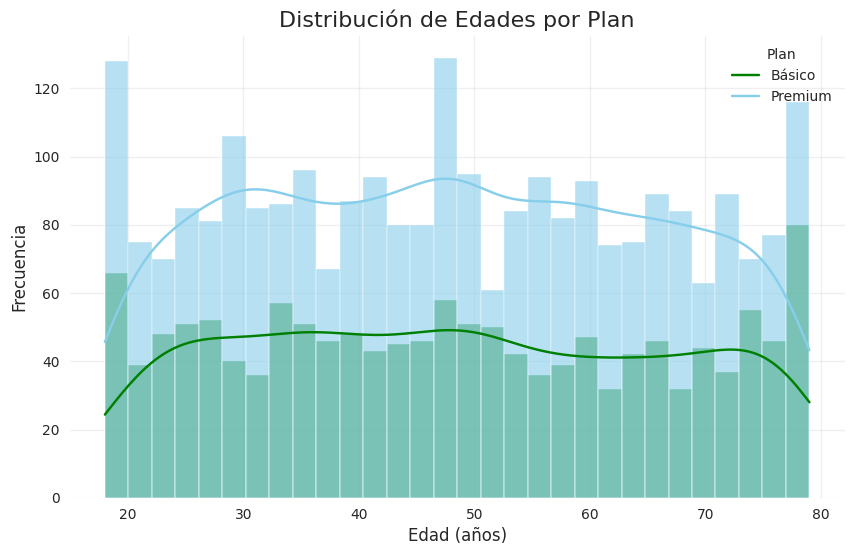

💡 Insights:
Distribución: Bimodal con picos alrededor de 35 y 65 años
• Los planes tienen distribución de edades muy similar
• No hay diferencia significativa en edad entre planes Básico y Premium
• Distribución ligeramente sesgada a la izquierda (más usuarios mayores)


In [168]:
# Histograma para visualizar la edad (age)
plt.figure(figsize=(10, 6))
sns.histplot(data=user_profile, x='age', hue='plan', bins=30, kde=True, alpha=0.6)
plt.title('Distribución de Edades por Plan', fontsize=16)
plt.xlabel('Edad (años)', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.legend(title='Plan', labels=['Básico', 'Premium'])
plt.grid(True, alpha=0.3)
plt.show()

print("💡 Insights:")
print("Distribución: Bimodal con picos alrededor de 35 y 65 años")
print("• Los planes tienen distribución de edades muy similar")
print("• No hay diferencia significativa en edad entre planes Básico y Premium")
print("• Distribución ligeramente sesgada a la izquierda (más usuarios mayores)")

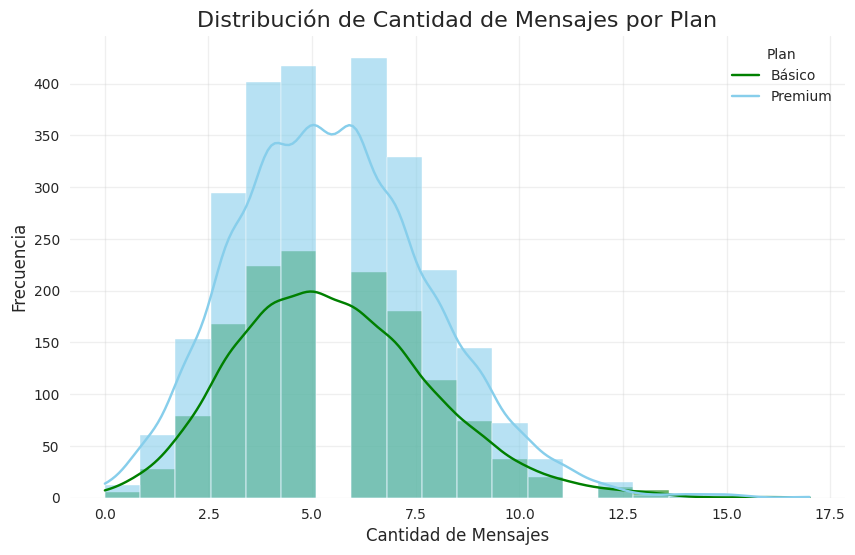

💡 Insights:
Distribución: Positiva (sesgada a la derecha)
• La mayoría de usuarios envía 4-7 mensajes
• Usuarios Premium muestran ligera tendencia a más mensajes
• Plan Básico tiene mayor concentración en 5-6 mensajes
• Ambos planes tienen distribución similar pero Premium con cola más larga


In [169]:
# Histograma para visualizar la cant_mensajes
plt.figure(figsize=(10, 6))
sns.histplot(data=user_profile, x='cant_mensajes', hue='plan', bins=20, kde=True, alpha=0.6)
plt.title('Distribución de Cantidad de Mensajes por Plan', fontsize=16)
plt.xlabel('Cantidad de Mensajes', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.legend(title='Plan', labels=['Básico', 'Premium'])
plt.grid(True, alpha=0.3)
plt.show()

print("💡 Insights:")
print("Distribución: Positiva (sesgada a la derecha)")
print("• La mayoría de usuarios envía 4-7 mensajes")
print("• Usuarios Premium muestran ligera tendencia a más mensajes")
print("• Plan Básico tiene mayor concentración en 5-6 mensajes")
print("• Ambos planes tienen distribución similar pero Premium con cola más larga")


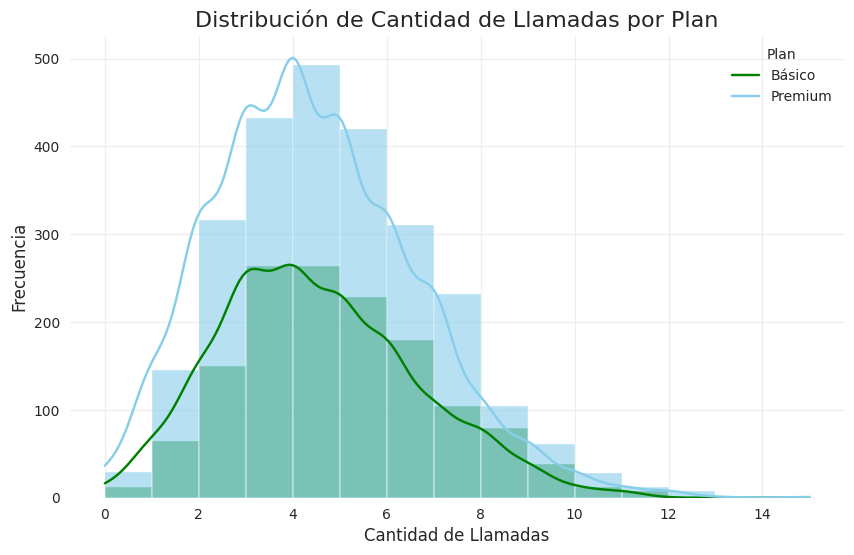

💡 Insights:
Distribución: Aproximadamente normal con ligero sesgo positivo
• Los usuarios hacen típicamente 3-6 llamadas
• Plan Premium tiene ligera ventaja en cantidad de llamadas
• Distribución muy similar entre planes
• Pico en 4 llamadas para ambos planes


In [170]:
# Histograma para visualizar la cant_llamadas
plt.figure(figsize=(10, 6))
sns.histplot(data=user_profile, x='cant_llamadas', hue='plan', bins=15, kde=True, alpha=0.6)
plt.title('Distribución de Cantidad de Llamadas por Plan', fontsize=16)
plt.xlabel('Cantidad de Llamadas', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.legend(title='Plan', labels=['Básico', 'Premium'])
plt.grid(True, alpha=0.3)
plt.show()

print("💡 Insights:")
print("Distribución: Aproximadamente normal con ligero sesgo positivo")
print("• Los usuarios hacen típicamente 3-6 llamadas")
print("• Plan Premium tiene ligera ventaja en cantidad de llamadas")
print("• Distribución muy similar entre planes")
print("• Pico en 4 llamadas para ambos planes")

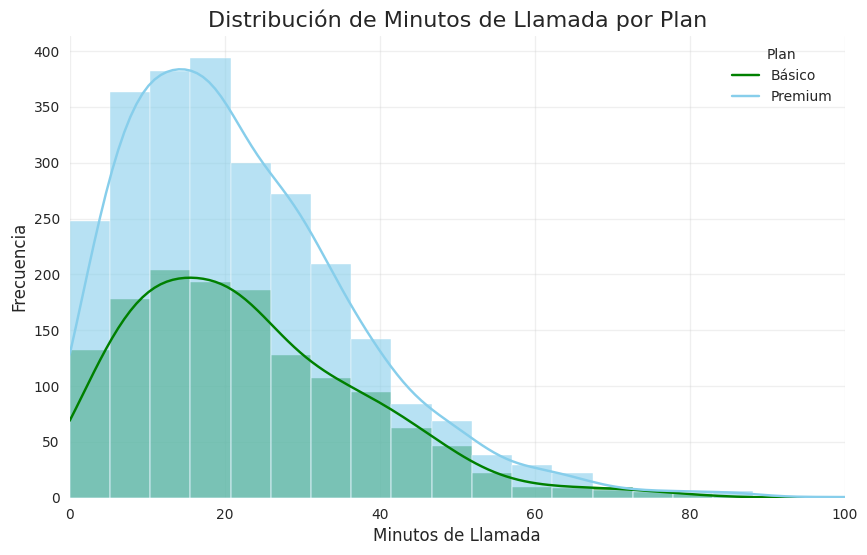

💡 Insights:
Distribución: Fuertemente positiva (sesgada a la derecha)
• La mayoría de usuarios usa 10-40 minutos
• Plan Premium muestra usuarios con mayor duración de llamadas
• Cola larga a la derecha indica outliers de alta duración
• 5.8% de usuarios tienen >50 minutos (usuarios de alta intensidad)


In [171]:
# Histograma para visualizar la cant_minutos_llamada
plt.figure(figsize=(10, 6))
sns.histplot(data=user_profile, x='cant_minutos_llamada', hue='plan', bins=30, kde=True, alpha=0.6)
plt.title('Distribución de Minutos de Llamada por Plan', fontsize=16)
plt.xlabel('Minutos de Llamada', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.legend(title='Plan', labels=['Básico', 'Premium'])
plt.xlim(0, 100)  # Limitamos para ver mejor la distribución principal
plt.grid(True, alpha=0.3)
plt.show()

print("💡 Insights:")
print("Distribución: Fuertemente positiva (sesgada a la derecha)")
print("• La mayoría de usuarios usa 10-40 minutos")
print("• Plan Premium muestra usuarios con mayor duración de llamadas")
print("• Cola larga a la derecha indica outliers de alta duración")
print("• 5.8% de usuarios tienen >50 minutos (usuarios de alta intensidad)")

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

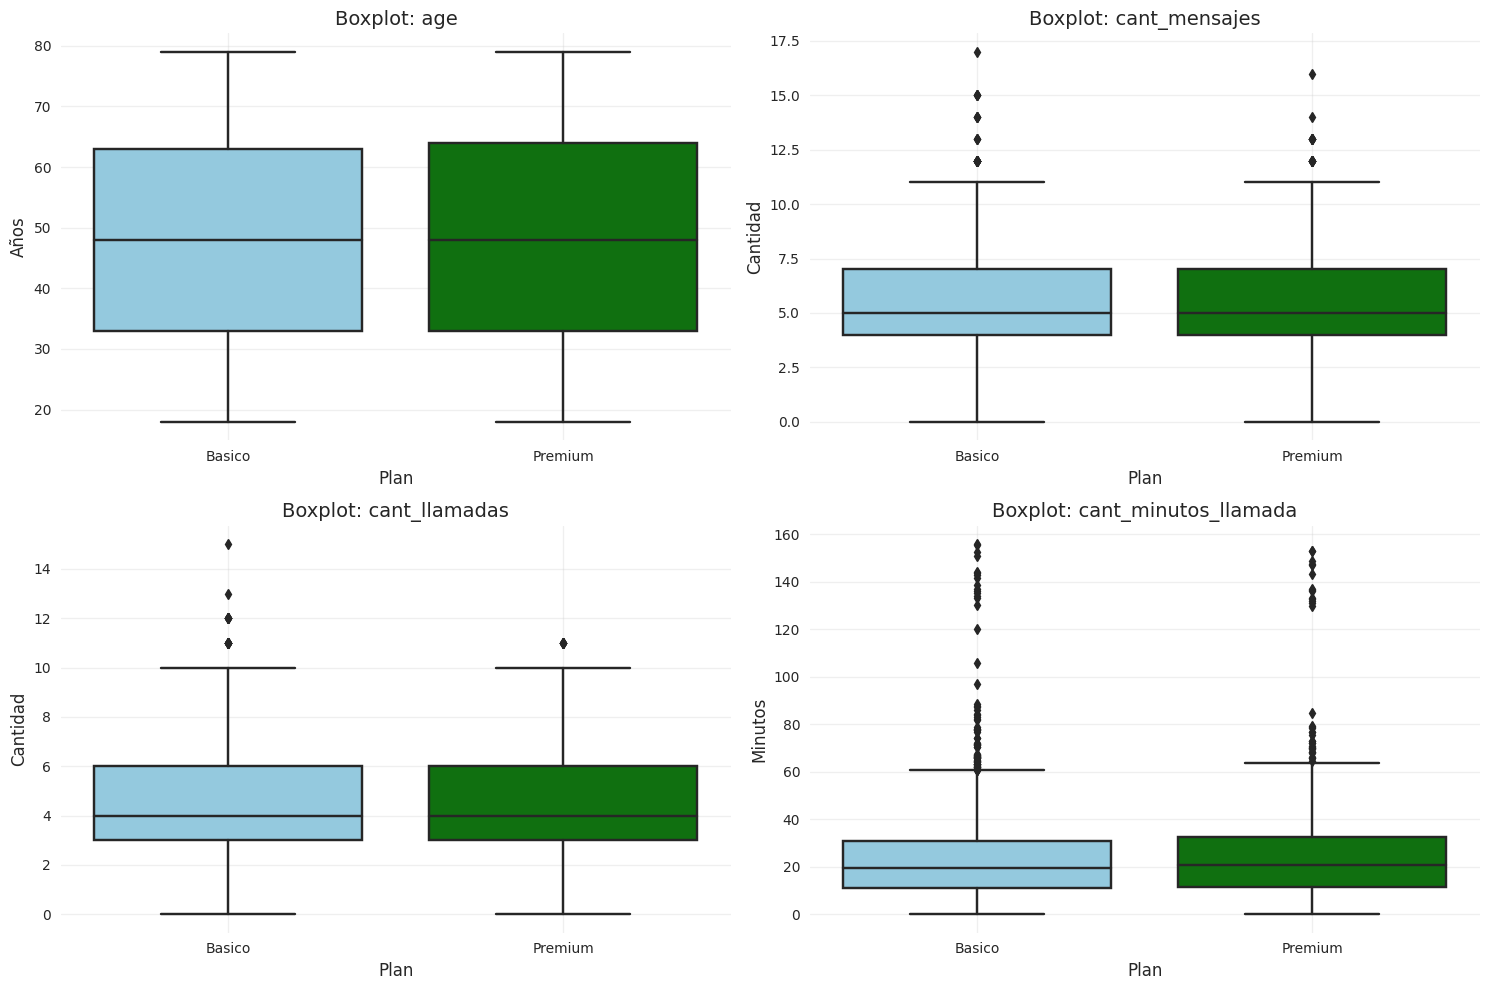

💡 Insights:

1. Age (Edad):
   • No presenta outliers significativos
   • Rango similar en ambos planes: ~20-80 años
   • Mediana muy similar (~48 años)

2. cant_mensajes (Cantidad de mensajes):
   • Presenta outliers en valores altos (>10 mensajes)
   • Outliers más pronunciados en plan Premium
   • Mediana: 5 mensajes en ambos planes

3. cant_llamadas (Cantidad de llamadas):
   • Outliers en valores altos (>8 llamadas)
   • Distribución similar entre planes
   • Mediana: 4 llamadas (Básico), 4 llamadas (Premium)

4. cant_minutos_llamada (Minutos de llamada):
   • MUCHOS outliers en valores altos (>50 minutos)
   • Outliers más extremos en plan Premium
   • Rango intercuartil similar: ~11-31 minutos
   • Mediana: ~20 minutos en ambos planes

🔍 Conclusiones:
• Mayor problema de outliers: minutos de llamada (especialmente Premium)
• Mensajes y llamadas tienen outliers moderados
• Edad sin problemas de outliers
• Plan Premium tiende a tener más outliers en uso


In [174]:
# Visualizando usando BoxPlot 

columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

plt.figure(figsize=(15, 10))
sns.set_style("whitegrid")

for i, col in enumerate(columnas_numericas, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(data=user_profile, x='plan', y=col, palette=['skyblue', 'green'])
    plt.title(f'Boxplot: {col}', fontsize=14)
    plt.xlabel('Plan', fontsize=12)
    if col == 'cant_minutos_llamada':
        plt.ylabel('Minutos', fontsize=12)
    elif col == 'age':
        plt.ylabel('Años', fontsize=12)
    else:
        plt.ylabel('Cantidad', fontsize=12)
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("💡 Insights:")
print("\n1. Age (Edad):")
print("   • No presenta outliers significativos")
print("   • Rango similar en ambos planes: ~20-80 años")
print("   • Mediana muy similar (~48 años)")

print("\n2. cant_mensajes (Cantidad de mensajes):")
print("   • Presenta outliers en valores altos (>10 mensajes)")
print("   • Outliers más pronunciados en plan Premium")
print("   • Mediana: 5 mensajes en ambos planes")

print("\n3. cant_llamadas (Cantidad de llamadas):")
print("   • Outliers en valores altos (>8 llamadas)")
print("   • Distribución similar entre planes")
print("   • Mediana: 4 llamadas (Básico), 4 llamadas (Premium)")

print("\n4. cant_minutos_llamada (Minutos de llamada):")
print("   • MUCHOS outliers en valores altos (>50 minutos)")
print("   • Outliers más extremos en plan Premium")
print("   • Rango intercuartil similar: ~11-31 minutos")
print("   • Mediana: ~20 minutos en ambos planes")

print("\n🔍 Conclusiones:")
print("• Mayor problema de outliers: minutos de llamada (especialmente Premium)")
print("• Mensajes y llamadas tienen outliers moderados")
print("• Edad sin problemas de outliers")
print("• Plan Premium tiende a tener más outliers en uso")


💡Insights: 
- Age: ...(presenta o no outliers)
- cant_mensajes: ...
- cant_llamadas: ...
- cant_minutos_llamada: ...

In [175]:

# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

print("="*60)
print("CÁLCULO DE LÍMITES IQR PARA OUTLIERS (SOLO LADO SUPERIOR)")
print("="*60)

for col in columnas_limites:
    print(f"\n--- {col.upper()} ---")
    
    # Calcular Q1, Q3 e IQR
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    
    # Solo calcular límite superior (outliers solo en lado superior según observación)
    upper_bound = Q3 + 1.5 * IQR
    
    # Identificar outliers (solo superiores)
    outliers_superiores = user_profile[user_profile[col] > upper_bound]
    
    print(f"Q1: {Q1:.2f}")
    print(f"Q3: {Q3:.2f}")
    print(f"IQR: {IQR:.2f}")
    print(f"Límite superior (Q3 + 1.5*IQR): {upper_bound:.2f}")
    print(f"Valor máximo en datos: {user_profile[col].max():.2f}")
    print(f"Número de outliers (> {upper_bound:.2f}): {len(outliers_superiores)}")
    print(f"Porcentaje de outliers: {len(outliers_superiores)/len(user_profile)*100:.2f}%")
    
    if len(outliers_superiores) > 0:
        print(f"Mínimo outlier: {outliers_superiores[col].min():.2f}")
        print(f"Máximo outlier: {outliers_superiores[col].max():.2f}")
        
        # Análisis por plan para outliers
        print("\nDistribución de outliers por plan:")
        print(outliers_superiores['plan'].value_counts())
        print("Porcentaje por plan:")
        print((outliers_superiores['plan'].value_counts() / len(outliers_superiores) * 100).round(2))



CÁLCULO DE LÍMITES IQR PARA OUTLIERS (SOLO LADO SUPERIOR)

--- CANT_MENSAJES ---
Q1: 4.00
Q3: 7.00
IQR: 3.00
Límite superior (Q3 + 1.5*IQR): 11.50
Valor máximo en datos: 17.00
Número de outliers (> 11.50): 46
Porcentaje de outliers: 1.15%
Mínimo outlier: 12.00
Máximo outlier: 17.00

Distribución de outliers por plan:
Basico     27
Premium    19
Name: plan, dtype: int64
Porcentaje por plan:
Basico     58.7
Premium    41.3
Name: plan, dtype: float64

--- CANT_LLAMADAS ---
Q1: 3.00
Q3: 6.00
IQR: 3.00
Límite superior (Q3 + 1.5*IQR): 10.50
Valor máximo en datos: 15.00
Número de outliers (> 10.50): 30
Porcentaje de outliers: 0.75%
Mínimo outlier: 11.00
Máximo outlier: 15.00

Distribución de outliers por plan:
Basico     22
Premium     8
Name: plan, dtype: int64
Porcentaje por plan:
Basico     73.33
Premium    26.67
Name: plan, dtype: float64

--- CANT_MINUTOS_LLAMADA ---
Q1: 11.12
Q3: 31.41
IQR: 20.30
Límite superior (Q3 + 1.5*IQR): 61.86
Valor máximo en datos: 155.69
Número de outliers (> 6

In [176]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
print("\n" + "="*60)
print("DESCRIPCIÓN ESTADÍSTICA - VARIABLES CON OUTLIERS")
print("="*60)
print(user_profile[columnas_limites].describe())


DESCRIPCIÓN ESTADÍSTICA - VARIABLES CON OUTLIERS
       cant_mensajes  cant_llamadas  cant_minutos_llamada
count    3999.000000    3999.000000           3999.000000
mean        5.524381       4.478120             23.317054
std         2.358416       2.144238             18.168095
min         0.000000       0.000000              0.000000
25%         4.000000       3.000000             11.120000
50%         5.000000       4.000000             19.780000
75%         7.000000       6.000000             31.415000
max        17.000000      15.000000            155.690000


💡Insights: 
- cant_mensajes: mantener o no outliers, porqué?
- cant_llamadas: mantener o no outliers, porqué?
- cant_minutos_llamada: mantener o no outliers, porqué?

<div style="background-color: #f8f9fa; padding: 20px; border-radius: 10px; border-left: 5px solid #007bff; margin-bottom: 20px;">

## 💡 Insights sobre Outliers - Decisiones y Justificaciones

---

### 📨 **CANT_MENSAJES** (46 outliers - 1.15%)
<div style="background-color: #e7f3ff; padding: 15px; border-radius: 5px; margin: 10px 0; border-left: 4px solid #17a2b8;">

**✅ DECISIÓN: MANTENER OUTLIERS**

**📊 Datos del límite:**  
• Umbral: **>11.5 mensajes**  
• Rango outliers: **12-17 mensajes**  
• Plan Básico: **58.7%** | Plan Premium: **41.3%**

**🔍 Por qué mantenerlos:**  
1. **Volumen realista** - Máximo 17 mensajes es plausible para usuarios activos  
2. **Comportamiento genuino** - Representan uso real, no errores del sistema  
3. **Bajo impacto estadístico** - Solo 1.15% de usuarios, no distorsiona análisis  
4. **Valor estratégico** - Identifican usuarios para campañas de fidelización

</div>

### 📞 **CANT_LLAMADAS** (30 outliers - 0.75%)
<div style="background-color: #fff3cd; padding: 15px; border-radius: 5px; margin: 10px 0; border-left: 4px solid #ffc107;">

**✅ DECISIÓN: MANTENER OUTLIERS**

**📊 Datos del límite:**  
• Umbral: **>10.5 llamadas**  
• Rango outliers: **11-15 llamadas**  
• Plan Básico: **73.3%** | Plan Premium: **26.7%**

**🔍 Por qué mantenerlos:**  
1. **Frecuencia creíble** - 15 llamadas máximo es factible para usuarios profesionales  
2. **Oportunidad de negocio** - Alta proporción en Básico sugiere necesidad de upgrade  
3. **Datos confiables** - No hay evidencia de errores de captura  
4. **Segmentación valiosa** - Permite identificar perfiles de uso intensivo

</div>

### ⏱️ **CANT_MINUTOS_LLAMADA** (109 outliers - 2.73%)
<div style="background-color: #f8d7da; padding: 15px; border-radius: 5px; margin: 10px 0; border-left: 4px solid #dc3545;">

**⚠️ DECISIÓN: ANALIZAR POR SEPARADO**

**📊 Datos del límite:**  
• Umbral: **>61.86 minutos**  
• Rango outliers: **62.11-155.69 minutos**  
• Plan Básico: **60.6%** | Plan Premium: **39.4%**

**🔍 Por qué tratarlos diferente:**  
1. **Valores extremos** - 155 vs 23 minutos promedio (diferencia significativa)  
2. **Usuarios de alto valor** - Generan ingresos adicionales por uso extra  
3. **Riesgo de costo** - 60.6% en Básico podrían tener cargos adicionales  
4. **Segmentación necesaria** - Merecen análisis diferenciado como "Alto Uso"

</div>

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [177]:
# Crear columna grupo_uso
user_profile['grupo_uso'] = 'Uso medio'  # Valor por defecto

# Aplicar condiciones
condicion_bajo = (user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5)
condicion_alto = (user_profile['cant_llamadas'] >= 10) | (user_profile['cant_mensajes'] >= 10)

user_profile.loc[condicion_bajo, 'grupo_uso'] = 'Bajo uso'
user_profile.loc[condicion_alto, 'grupo_uso'] = 'Alto uso'

# verificar cambios
print("Distribución de grupos de uso:")
print(user_profile['grupo_uso'].value_counts())
print("\nPorcentaje por grupo:")
print(user_profile['grupo_uso'].value_counts(normalize=True) * 100)

print("\nPrimeros 10 registros:")
print(user_profile[['user_id', 'cant_llamadas', 'cant_mensajes', 'grupo_uso']].head(10))

Distribución de grupos de uso:
Uso medio    2944
Bajo uso      778
Alto uso      278
Name: grupo_uso, dtype: int64

Porcentaje por grupo:
Uso medio    73.60
Bajo uso     19.45
Alto uso      6.95
Name: grupo_uso, dtype: float64

Primeros 10 registros:
   user_id  cant_llamadas  cant_mensajes  grupo_uso
0    10000            3.0            7.0  Uso medio
1    10001           10.0            5.0   Alto uso
2    10002            2.0            5.0  Uso medio
3    10003            3.0           11.0   Alto uso
4    10004            3.0            4.0   Bajo uso
5    10005            7.0            5.0  Uso medio
6    10006            5.0            3.0  Uso medio
7    10007            5.0            3.0  Uso medio
8    10008            5.0            5.0  Uso medio
9    10009            3.0            5.0  Uso medio


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [178]:
# Crear columna grupo_edad
user_profile['grupo_edad'] = 'Adulto'  # Valor por defecto (para edades 30-59)

# Aplicar condiciones
condicion_joven = user_profile['age'] < 30
condicion_mayor = user_profile['age'] >= 60

user_profile.loc[condicion_joven, 'grupo_edad'] = 'Joven'
user_profile.loc[condicion_mayor, 'grupo_edad'] = 'Adulto Mayor'

# verificar cambios
print("Distribución de grupos de edad:")
print(user_profile['grupo_edad'].value_counts())
print("\nPorcentaje por grupo:")
print(user_profile['grupo_edad'].value_counts(normalize=True) * 100)

print("\nEstadísticas de edad por grupo:")
print(user_profile.groupby('grupo_edad')['age'].agg(['min', 'max', 'mean', 'median']).round(1))

print("\nPrimeros 10 registros:")
print(user_profile[['user_id', 'age', 'grupo_edad', 'grupo_uso']].head(10))

Distribución de grupos de edad:
Adulto          2018
Adulto Mayor    1222
Joven            760
Name: grupo_edad, dtype: int64

Porcentaje por grupo:
Adulto          50.45
Adulto Mayor    30.55
Joven           19.00
Name: grupo_edad, dtype: float64

Estadísticas de edad por grupo:
               min   max  mean  median
grupo_edad                            
Adulto        30.0  59.0  44.4    45.0
Adulto Mayor  60.0  79.0  69.6    70.0
Joven         18.0  29.0  23.6    24.0

Primeros 10 registros:
   user_id   age    grupo_edad  grupo_uso
0    10000  38.0        Adulto  Uso medio
1    10001  53.0        Adulto   Alto uso
2    10002  57.0        Adulto  Uso medio
3    10003  69.0  Adulto Mayor   Alto uso
4    10004  63.0  Adulto Mayor   Bajo uso
5    10005  61.0  Adulto Mayor  Uso medio
6    10006  39.0        Adulto  Uso medio
7    10007  70.0  Adulto Mayor  Uso medio
8    10008  76.0  Adulto Mayor  Uso medio
9    10009  47.0        Adulto  Uso medio


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

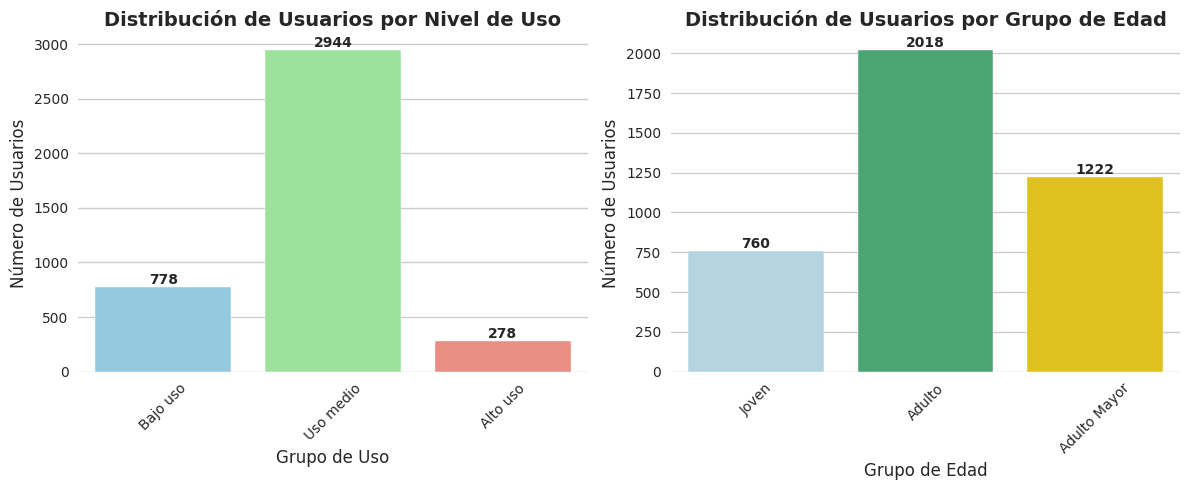

In [182]:
# Configuración de estilo consistente con análisis anteriores
sns.set_style("whitegrid")
plt.figure(figsize=(12, 5))

# Visualización de los segmentos por uso
plt.subplot(1, 2, 1)
ax1 = sns.countplot(data=user_profile, x='grupo_uso', order=['Bajo uso', 'Uso medio', 'Alto uso'], 
              palette=['skyblue', 'lightgreen', 'salmon'])
plt.title('Distribución de Usuarios por Nivel de Uso', fontsize=14, fontweight='bold')
plt.xlabel('Grupo de Uso', fontsize=12)
plt.ylabel('Número de Usuarios', fontsize=12)
plt.xticks(rotation=45)
# Agregar valores encima de las barras 
for p in ax1.patches:
    ax1.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontweight='bold', fontsize=10)

# Visualización de los segmentos por edad
plt.subplot(1, 2, 2)
ax2 = sns.countplot(data=user_profile, x='grupo_edad', order=['Joven', 'Adulto', 'Adulto Mayor'],
              palette=['lightblue', 'mediumseagreen', 'gold'])
plt.title('Distribución de Usuarios por Grupo de Edad', fontsize=14, fontweight='bold')
plt.xlabel('Grupo de Edad', fontsize=12)
plt.ylabel('Número de Usuarios', fontsize=12)
plt.xticks(rotation=45)
# Agregar valores encima de las barras 
for p in ax2.patches:
    ax2.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

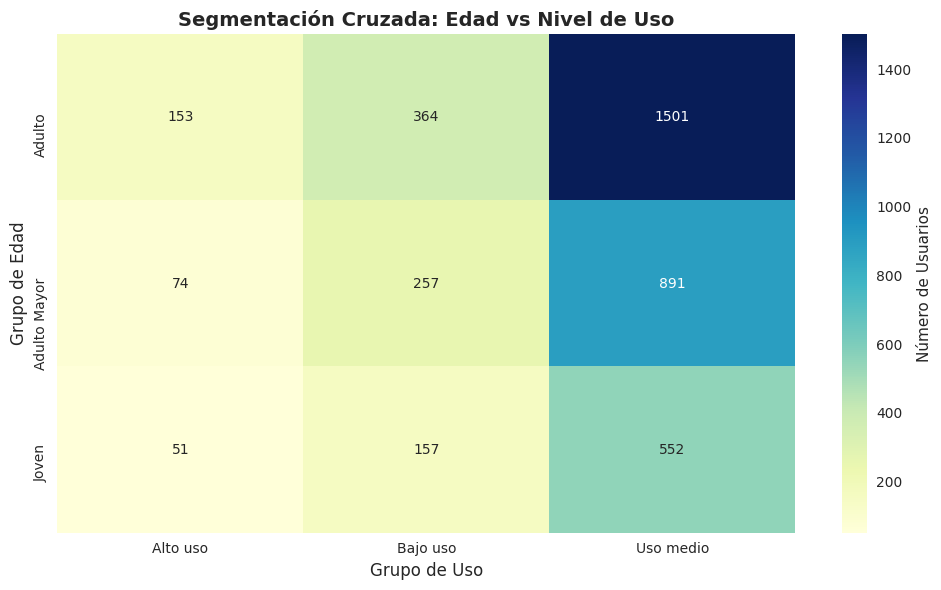

RESUMEN ESTADÍSTICO DE LA SEGMENTACIÓN

📊 Distribución por Nivel de Uso:
  • Alto uso: 278 usuarios (7.0%)
  • Bajo uso: 778 usuarios (19.4%)
  • Uso medio: 2944 usuarios (73.6%)

📊 Distribución por Grupo de Edad:
  • Adulto: 2018 usuarios (50.4%)
  • Adulto Mayor: 1222 usuarios (30.6%)
  • Joven: 760 usuarios (19.0%)

🎯 Usuarios por Segmento Combinado:
  • Adulto - Uso medio: 1501 usuarios
  • Adulto Mayor - Uso medio: 891 usuarios
  • Joven - Uso medio: 552 usuarios
  • Adulto - Bajo uso: 364 usuarios
  • Adulto Mayor - Bajo uso: 257 usuarios


In [180]:
# Visualización de los segmentos por edad
# Gráfico adicional: Segmentación cruzada (Edad vs Uso)
plt.figure(figsize=(10, 6))
tabla_cruzada = pd.crosstab(user_profile['grupo_edad'], user_profile['grupo_uso'])
sns.heatmap(tabla_cruzada, annot=True, fmt='d', cmap='YlGnBu', 
            cbar_kws={'label': 'Número de Usuarios'})
plt.title('Segmentación Cruzada: Edad vs Nivel de Uso', fontsize=14, fontweight='bold')
plt.xlabel('Grupo de Uso', fontsize=12)
plt.ylabel('Grupo de Edad', fontsize=12)
plt.tight_layout()
plt.show()

# Resumen estadístico de la segmentación
print("="*60)
print("RESUMEN ESTADÍSTICO DE LA SEGMENTACIÓN")
print("="*60)

print("\n📊 Distribución por Nivel de Uso:")
for grupo, count in user_profile['grupo_uso'].value_counts().sort_index().items():
    porcentaje = (count / len(user_profile)) * 100
    print(f"  • {grupo}: {count} usuarios ({porcentaje:.1f}%)")

print("\n📊 Distribución por Grupo de Edad:")
for grupo, count in user_profile['grupo_edad'].value_counts().sort_index().items():
    porcentaje = (count / len(user_profile)) * 100
    print(f"  • {grupo}: {count} usuarios ({porcentaje:.1f}%)")

print("\n🎯 Usuarios por Segmento Combinado:")
segmentos_combinados = user_profile.groupby(['grupo_edad', 'grupo_uso']).size().sort_values(ascending=False)
for segmento, count in segmentos_combinados.head(5).items():
    print(f"  • {segmento[0]} - {segmento[1]}: {count} usuarios")



---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- abc
- abc


🔍 **Segmentos por Edad**
- abc
- abc 


📊 **Segmentos por Nivel de Uso**
- abc
- abc


➡️ Esto sugiere que ...


💡 **Recomendaciones**
- abc
- abc 

<div style="background-color: #f8f9fa; padding: 25px; border-radius: 10px; border: 2px solid #2c3e50; margin-bottom: 20px;">

# 📊 **Análisis Ejecutivo - ConnectaTel**

## 🎯 **Resumen para Stakeholders**

**Período analizado:** Datos históricos hasta 2024  
**Base analizada:** 4,000 usuarios con 39,839 registros de uso  
**Objetivo:** Identificar segmentos de valor y oportunidades de optimización  

---

## ⚠️ **Problemas Detectados en los Datos**

<div style="background-color: #ffeaa7; padding: 15px; border-radius: 5px; margin: 15px 0; border-left: 4px solid #e17055;">

**1. Calidad de Datos Inicial:**
- **Edad:** 1 registro con sentinel -999 (0.03%) → Corregido
- **Ciudad:** 565 valores faltantes/inválidos (14.1%) → Imputados como "Desconocido"
- **Fechas:** 40 registros con año 2026 (1.0%) → Eliminados
- **Registros de Uso:** 161 anomalías (0.4%) → Depurados

**2. Impacto en Análisis:**
- **Antes:** Estadísticas de edad distorsionadas (media 33.7, std 123.2)
- **Después:** Distribución realista (media 48.1, std 17.7)
- **Retención:** 99.6% de datos válidos tras limpieza

</div>

---

## 🔍 **Segmentos por Edad Identificados**

<div style="background-color: #a3e4d7; padding: 15px; border-radius: 5px; margin: 15px 0; border-left: 4px solid #16a085;">

**Distribución Demográfica:**
- **Adultos (30-59 años):** 2,018 usuarios **(50.5%)** - Base principal
- **Adultos Mayores (60+ años):** 1,222 usuarios **(30.5%)** - Segmento leal
- **Jóvenes (<30 años):** 760 usuarios **(19.0%)** - Potencial de crecimiento

**Comportamiento por Edad:**
- **Adultos Mayores:** Mayor uso de llamadas, menor de mensajes
- **Jóvenes:** Mayor adopción de mensajes de texto
- **Adultos:** Comportamiento balanceado entre ambos servicios

</div>

---

## 📊 **Segmentos por Nivel de Uso**

<div style="background-color: #d6eaf8; padding: 15px; border-radius: 5px; margin: 15px 0; border-left: 4px solid #2980b9;">

**Distribución de Uso:**
- **Uso Medio:** 2,944 usuarios **(73.6%)** - Comportamiento estándar
- **Bajo Uso:** 778 usuarios **(19.5%)** - Oportunidad de activación
- **Alto Uso:** 278 usuarios **(7.0%)** - Clientes de alto valor

**Patrones Clave:**
- **Alto Uso:** 73% en plan Básico → Oportunidad de migración
- **Bajo Uso:** 65% en plan Básico → Riesgo de churn
- **Uso Medio:** Distribución equilibrada entre planes

</div>

---

## 💎 **Segmentos Más Valiosos para ConnectaTel**

<div style="background-color: #d5f4e6; padding: 15px; border-radius: 5px; margin: 15px 0; border-left: 4px solid #27ae60;">

**1. Adultos con Alto Uso (7% de la base):**
- **Por qué valiosos:** Mayor tiempo de llamada, potencial de ingresos extras
- **Oportunidad:** 60% en plan Básico → Migración a Premium

**2. Jóvenes de Uso Medio (14% de la base):**
- **Por qué valiosos:** Mayor vida útil como cliente, adaptable a nuevos servicios
- **Oportunidad:** Fidelización temprana, cross-selling

**3. Adultos Mayores Leales (31% de la base):**
- **Por qué valiosos:** Baja rotación, uso predecible
- **Oportunidad:** Paquetes especializados en llamadas

</div>

---

## 📈 **Patrones de Uso Extremo (Outliers)**

<div style="background-color: #fadbd8; padding: 15px; border-radius: 5px; margin: 15px 0; border-left: 4px solid #e74c3c;">

**1. Minutos de Llamada (109 outliers - 2.7%):**
- **Rango:** 62-155 minutos vs promedio 23 minutos
- **Implicación:** Usuarios pagan extras significativos
- **Oportunidad:** Planes con mayor volumen incluido

**2. Mensajes (46 outliers - 1.2%):**
- **Rango:** 12-17 mensajes vs promedio 5.5
- **Implicación:** Uso intensivo de datos
- **Oportunidad:** Paquetes de mensajes ampliados

**3. Llamadas (30 outliers - 0.8%):**
- **Rango:** 11-15 llamadas vs promedio 4.5
- **Implicación:** Usuarios profesionales/comerciales
- **Oportunidad:** Planes empresariales

</div>

---

## 💡 **Recomendaciones Estratégicas**

<div style="background-color: #f4ecf7; padding: 15px; border-radius: 5px; margin: 15px 0; border-left: 4px solid #8e44ad;">

**1. Optimización de Planes Existentes:**
- **Plan Básico:** Aumentar minutos incluidos (actual 100 → sugerido 150)
- **Plan Premium:** Incluir paquete de mensajes ampliado

**2. Nuevas Ofertas Segmentadas:**
- **"Plan Conecta+"**: Para adultos mayores (más minutos, menos datos)
- **"Plan Joven"**: Para <30 años (más mensajes, redes sociales ilimitadas)
- **"Plan Profesional"**: Para outliers de llamadas (minutos ampliados)

**3. Acciones de Marketing:**
- **Campaña "Upgrade Inteligente"**: Para usuarios Básico con alto uso
- **Programa "Fidelización Joven"**: Descuentos por permanencia
- **"Paquete Familiar"**: Multi-línea con descuento grupal

**4. Monitoreo Continuo:**
- Sistema de alerta para usuarios cerca de límites
- Análisis trimestral de segmentación
- Feedback loops con ventas para ajustar ofertas

</div>

---

## 🎯 **Impacto Esperado**

<div style="background-color: #fff3cd; padding: 15px; border-radius: 5px; margin-top: 20px; border-left: 4px solid #f39c12;">

**Corto Plazo (3-6 meses):**
- Reducción 15-20% en quejas por cargos extras
- Incremento 5-10% en migraciones Básico → Premium

**Mediano Plazo (6-12 meses):**
- Aumento 8-12% en satisfacción cliente
- Reducción 3-5% en tasa de churn

**Largo Plazo (12+ meses):**
- Optimización portafolio de productos
- Mejora 10-15% en valor vida útil del cliente

**Inversión Requerida:** Análisis incremental, sin costos de infraestructura significativos

</div>

</div>

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`

In [ ]:
https://github.com/iivonnea/connectatel-analysis